In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [ ]:
# Example: Apple stock
data = yf.download("AAPL", start="2015-01-01", end="2023-01-01")

data = data[['Close']]
data.dropna(inplace=True)

data.head()

/tmp/ipython-input-163/150840669.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.214897
2015-01-05,23.532721
2015-01-06,23.534937
2015-01-07,23.864946
2015-01-08,24.781889


In [ ]:
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

In [ ]:
window = 5
moving_avg = train['Close'].rolling(window=window).mean()

# Forecast
ma_forecast = [train['Close'].iloc[-window:].mean()] * len(test)

mae_ma = mean_absolute_error(test['Close'], ma_forecast)
rmse_ma = np.sqrt(mean_squared_error(test['Close'], ma_forecast))

print("Moving Average MAE:", mae_ma)
print("Moving Average RMSE:", rmse_ma)

Moving Average MAE: 25.971642986893947
Moving Average RMSE: 29.03755655176277


In [ ]:
model_es = ExponentialSmoothing(train['Close'], trend='add', seasonal=None)
fit_es = model_es.fit()

es_forecast = fit_es.forecast(len(test))

mae_es = mean_absolute_error(test['Close'], es_forecast)
rmse_es = np.sqrt(mean_squared_error(test['Close'], es_forecast))

print("Exponential Smoothing MAE:", mae_es)
print("Exponential Smoothing RMSE:", rmse_es)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Exponential Smoothing MAE: 16.07817476360142
Exponential Smoothing RMSE: 19.624371349673805


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
model_arima = ARIMA(train['Close'], order=(5,1,0))
fit_arima = model_arima.fit()

arima_forecast = fit_arima.forecast(steps=len(test))

mae_arima = mean_absolute_error(test['Close'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Close'], arima_forecast))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA MAE: 25.855947198246668
ARIMA RMSE: 28.92969042970549


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


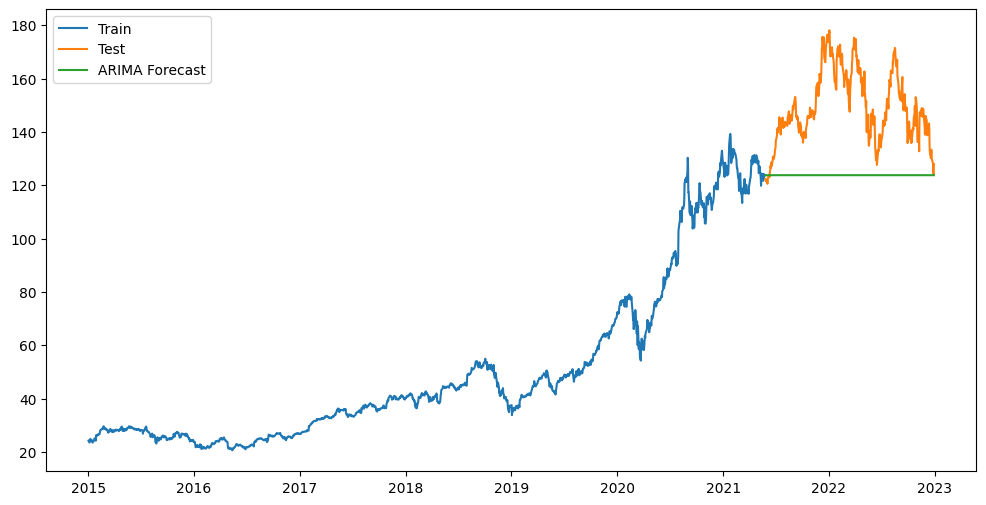

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Close'], label="Train")
plt.plot(test.index, test['Close'], label="Test")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.show()